# Project Overview & Problem Statement
<p> The marketing team aims to understand its target customers to plan a more effective strategy
The objective is to identify the most important shopping groups based on income, age, and mall spending scores

To divide the target market into digestible, approachable groups (subsets) based on demographics and shopping behavior to optimize marketing spend.</p>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

# Filter package conflict warnings for a clean report
warnings.filterwarnings('ignore')
sns.set(style="whitegrid") # Professional visual setting

# Load dataset and check structure
df = pd.read_csv('/Library/DAP/python_customer_segmentation/Datasets/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


We introduce a **Spend-to-Income Ratio**. This helps identify "High-Efficiency" shoppers who convert a large portion of their earnings into mall spending, regardless of their raw salary level.

In [2]:
df['Spend_Income_Ratio'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']
df['Spend_Income_Ratio'].describe()

count    200.000000
mean       1.068544
std        0.973406
min        0.012821
25%        0.632803
50%        0.887993
75%        1.130245
max        5.400000
Name: Spend_Income_Ratio, dtype: float64

# Univariate Exploratory Data Analysis (EDA)
We analyze individual variables to understand distributions and identify outliers

In [3]:
# Statistical Summary of the dataset
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.068544
std,57.879185,13.969007,26.264721,25.823522,0.973406
min,1.000000,18.000000,15.000000,1.000000,0.012821
25%,50.750000,28.750000,41.500000,34.750000,0.632803
50%,100.500000,36.000000,61.500000,50.000000,0.887993
75%,150.250000,49.000000,78.000000,73.000000,1.130245
max,200.000000,70.000000,137.000000,99.000000,5.400000


<Figure size 640x480 with 0 Axes>

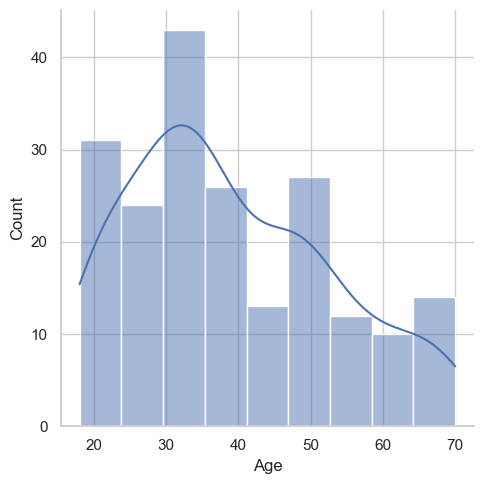

<Figure size 640x480 with 0 Axes>

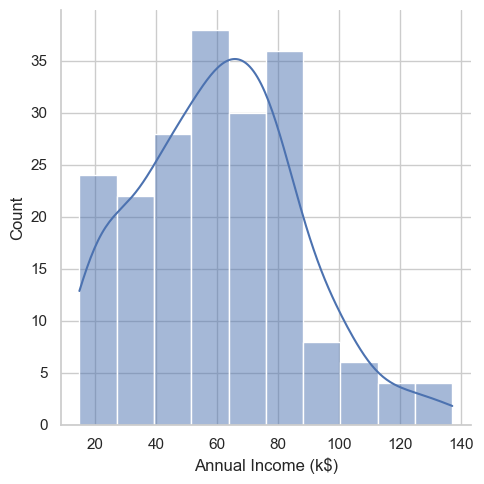

<Figure size 640x480 with 0 Axes>

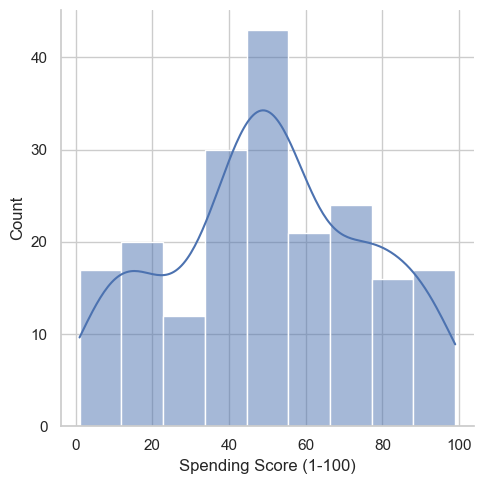

In [4]:
# Define the list of numerical columns for batch visualization
columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
# Use a for-loop to iterate through columns and create individual distribution plots
# The 'kde=True' parameter adds a Kernel Density Estimate line to show probability density
for i in columns:
    plt.figure()
    sns.displot(df[i], kde=True) # kde=True shows probability density curve

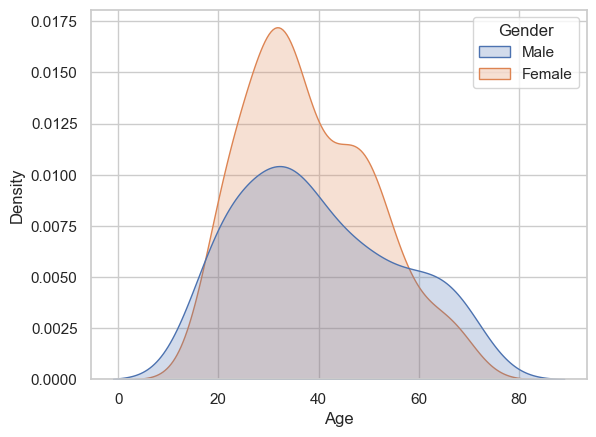

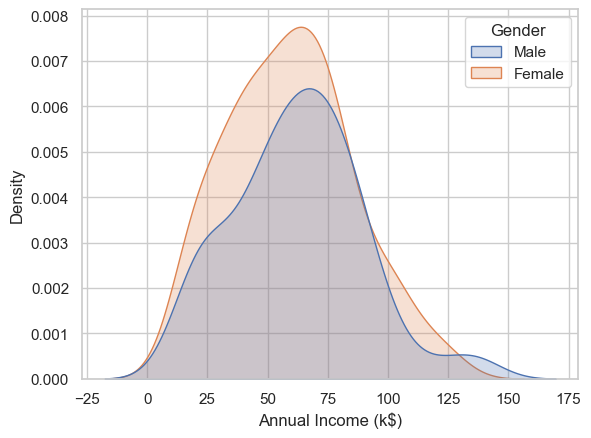

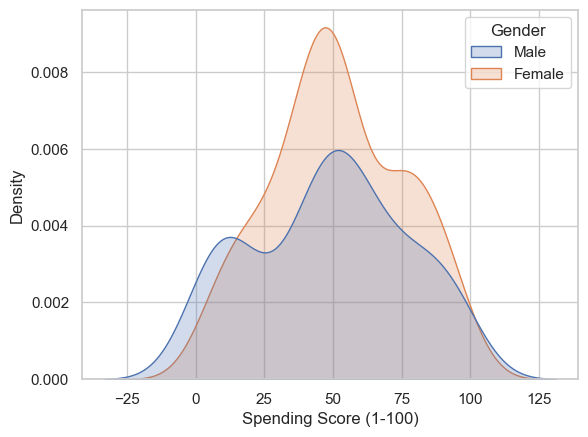

In [ ]:
# Gender-Based Density Analysis 
# Insight: Identifying "fat tails" or distribution shifts between genders can reveal significant behavioral differences in spending patterns and income levels.
for i in columns:
    plt.figure()
    sns.kdeplot(data=df, x=i, hue='Gender', fill=True, shade=True)

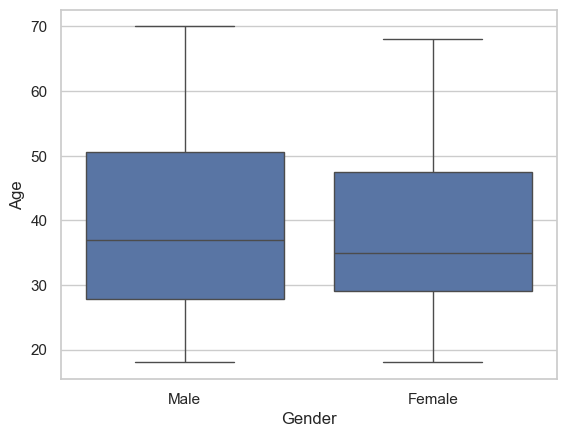

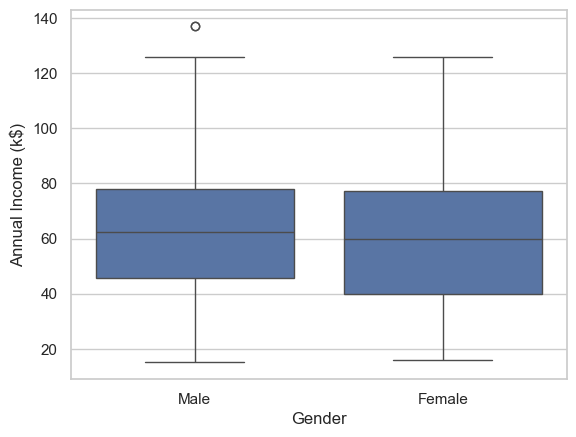

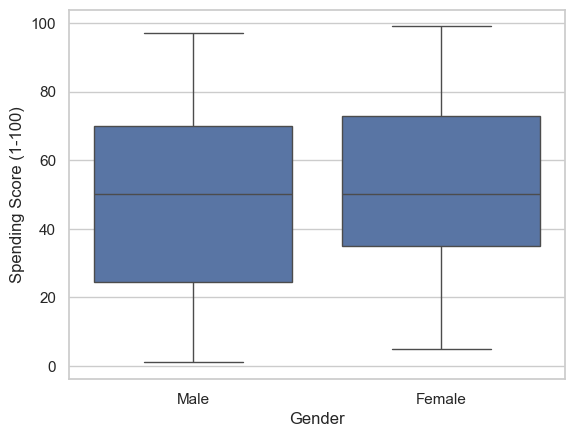

In [6]:
# Generate boxplots to visualize the spread and identify mathematical outliers
# Setting 'x' to Gender helps isolate which demographic contains specific outliers
for i in columns:
    plt.figure()
    sns.boxplot(data=df, x='Gender', y=df[i]);

In [7]:
# Demographic Distribution (Normalized)
# Finding: 56% Female vs 44% Male
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

# Bivariate & Correlation Analysis
Examining relationships between pairs of variables to find initial visual clusters

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

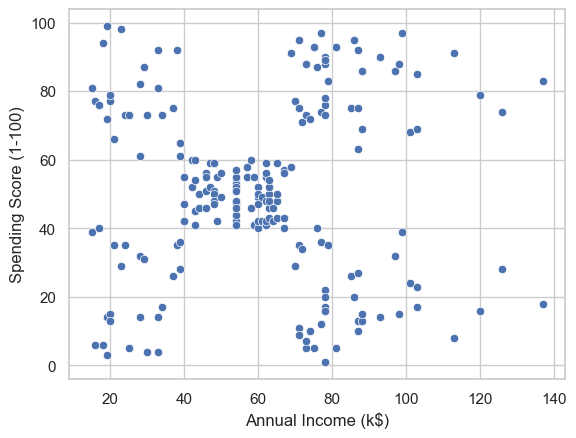

In [8]:
# Identifying visual clusters between Income and Spend
# Visual inspection suggests 5 primary clusters
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')

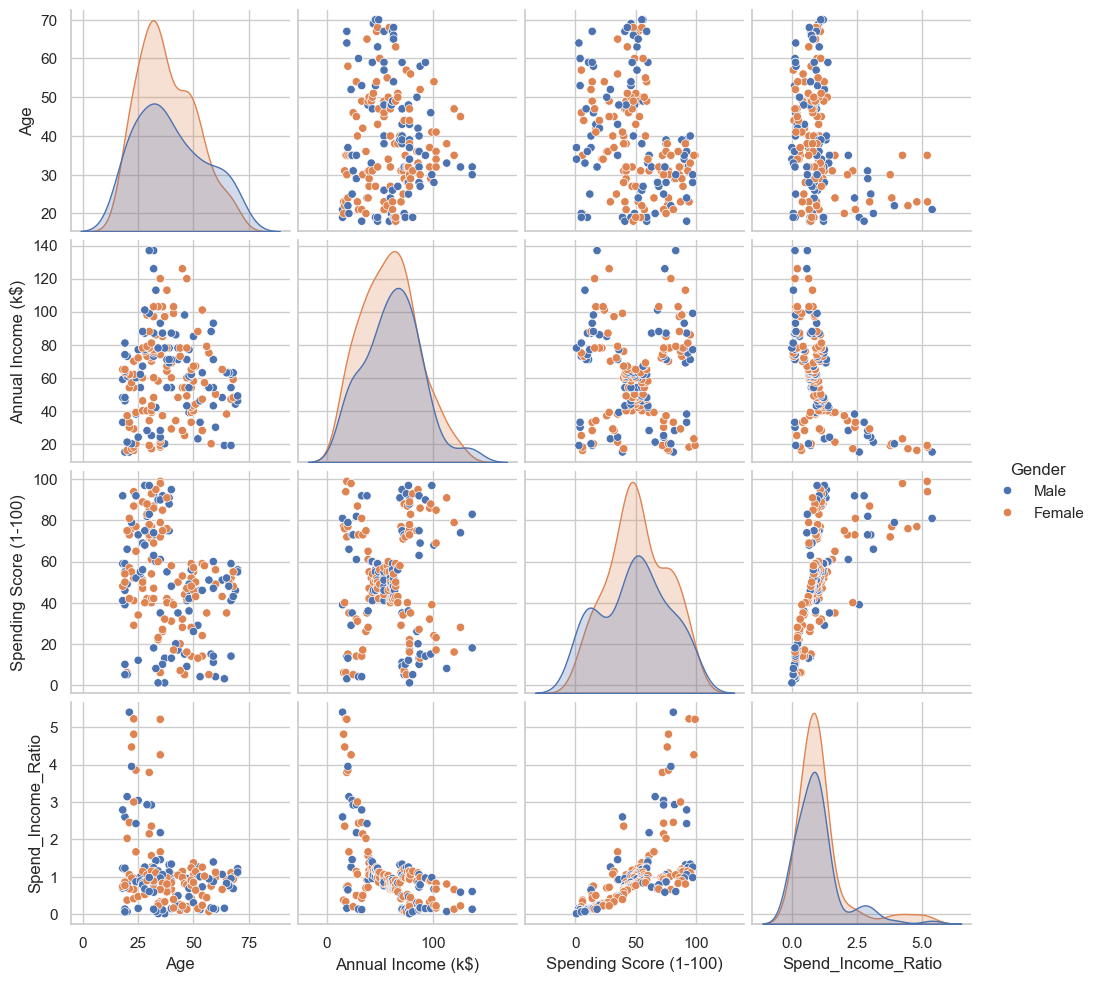

In [9]:
# Drop CustomerID as it lacks analytical value for pattern recognition
# Create a pair plot to visualize relationships across all numerical variables, segmented by Gender
df_pair = df.drop(columns=['CustomerID']) 
sns.pairplot(df_pair, hue='Gender');

In [10]:
# Group the data by Gender and calculate the mean for numerical attributes
# This identifies baseline differences in behavior between demographic groups
df_pair.groupby('Gender').mean()

,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio
Gender,,,,
Female,38.098214,59.250000,51.526786,1.119093
Male,39.806818,62.227273,48.511364,1.004208


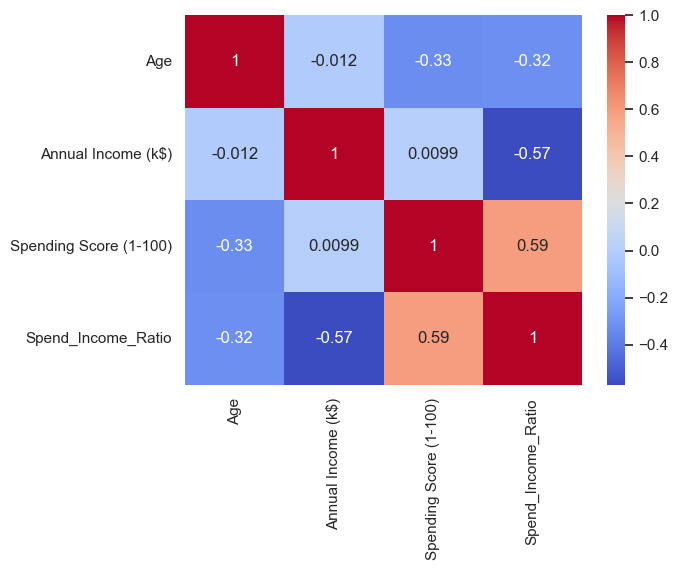

In [11]:
# Generate a correlation matrix for numerical variables
# Create a heatmap with annotations and a 'coolwarm' color map for better readability
sns.heatmap(df_pair.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm');

# Univariate Clustering and the Elbow Method

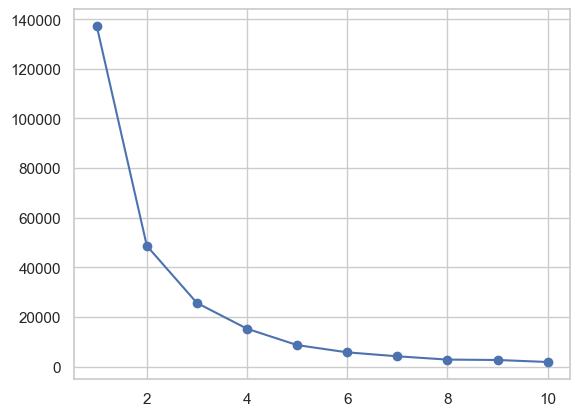

In [12]:
# Initialize an empty list to store inertia scores (Within-Cluster Sum of Squares)
inertia_scores = []

# Loop through 1 to 10 clusters to find the mathematical 'elbow'
for i in range(1, 11):
    # Initialize KMeans with the current number of clusters (i)
    kmeans = KMeans(n_clusters=i)
    # Fit the model specifically to the Annual Income column
    # Note: Double brackets are required to pass the data as a DataFrame, not a Series
    kmeans.fit(df[['Annual Income (k$)']])
    # Append the resulting inertia score to our list
    inertia_scores.append(kmeans.inertia_)

# Plot the inertia scores against the number of clusters
# This visual helps identify the point where adding more clusters provides diminishing returns
plt.plot(range(1, 11), inertia_scores, marker='o');

In [13]:
# Initialize the final univariate model with the optimized K of 3
clustering1 = KMeans(n_clusters=3)

# Fit the model to the Annual Income data
clustering1.fit(df[['Annual Income (k$)']])

# Assign the generated cluster labels back to the dataframe as a new column
df['Income Cluster'] = clustering1.labels_

# View the first few rows to confirm the labels (0, 1, or 2) are correctly assigned
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio,Income Cluster
0,1,Male,19,15,39,2.600000,1
1,2,Male,21,15,81,5.400000,1
2,3,Female,20,16,6,0.375000,1
3,4,Female,23,16,77,4.812500,1
4,5,Female,31,17,40,2.352941,1


In [14]:
# Check the number of customers assigned to each income-based cluster
df['Income Cluster'].value_counts()

# Group by the new clusters and calculate the mean for all numerical attributes
# Including our custom 'Spend_Income_Ratio' to find unique behavioral insights
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spend_Income_Ratio']].mean()

,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio
Income Cluster,,,,
0,37.833333,99.888889,50.638889,0.516440
1,38.930556,33.027778,50.166667,1.735155
2,39.184783,66.717391,50.054348,0.762889


### Univariate Reflection: 
The single variable analysis confirms 3 clear income tiers (Low, Middle, and High earners). However, income alone doesn't tell the whole story. Some high earners spend very little, while some low earners spend a lot. To understand these behaviors, we need to move beyond single variables and perform Bivariate clustering.

# Bivariate Clustering (Income vs. Spending)
While univariate analysis provided a baseline, shopping behavior is best defined by the relationship between Annual Income and Spending Score. We will now use the Elbow Method to mathematically determine the optimal number of segments for this specific pairing

Text(0, 0.5, 'Inertia')

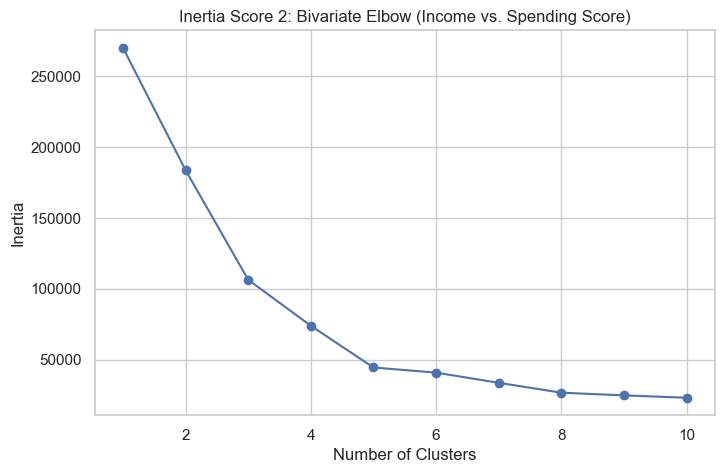

In [15]:
# Initialize an empty list for the second set of inertia scores
inertia_scores2 = []

# Loop through 1 to 10 clusters to find the mathematical elbow for bivariate data
for i in range(1, 11):
    # Use k-means++ initialization for better centroid placement
    kmeans2 = KMeans(n_clusters=i, init='k-means++', random_state=42)
    # Fit the model to both Annual Income and Spending Score
    kmeans2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    inertia_scores2.append(kmeans2.inertia_)

# Plot the bivariate elbow curve
# Observation: The elbow typically appears at 5 clusters for this pairing
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_scores2, marker='o')
plt.title('Inertia Score 2: Bivariate Elbow (Income vs. Spending Score)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')


### Executing Bivariate Clustering
Based on the elbow plot, we will fit the final model using 5 clusters. This allows us to identify the "high income/high spend" and "low income/high spend" groups.


In [16]:
# Initialize the bivariate model with 5 clusters
clustering2 = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Fit the model and assign the labels to a new column
clustering2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
df['Spending_and_Income_Cluster'] = clustering2.labels_

# View the head of the dataframe to see the newly assigned bivariate labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio,Income Cluster,Spending_and_Income_Cluster
0,1,Male,19,15,39,2.600000,1,4
1,2,Male,21,15,81,5.400000,1,2
2,3,Female,20,16,6,0.375000,1,4
3,4,Female,23,16,77,4.812500,1,2
4,5,Female,31,17,40,2.352941,1,4


In [17]:
# Analyze the averages for our 5 segments
df.groupby('Spending_and_Income_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending_and_Income_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Bivariate Reflection:
By adding the Spending Score to our analysis, we can see the data naturally breaks into 5 groups instead of 3. For example, we can now clearly separate the people who have high incomes but spend very little from the people who have high incomes and spend a lot. This gives us much better targeting options than just looking at income alone.

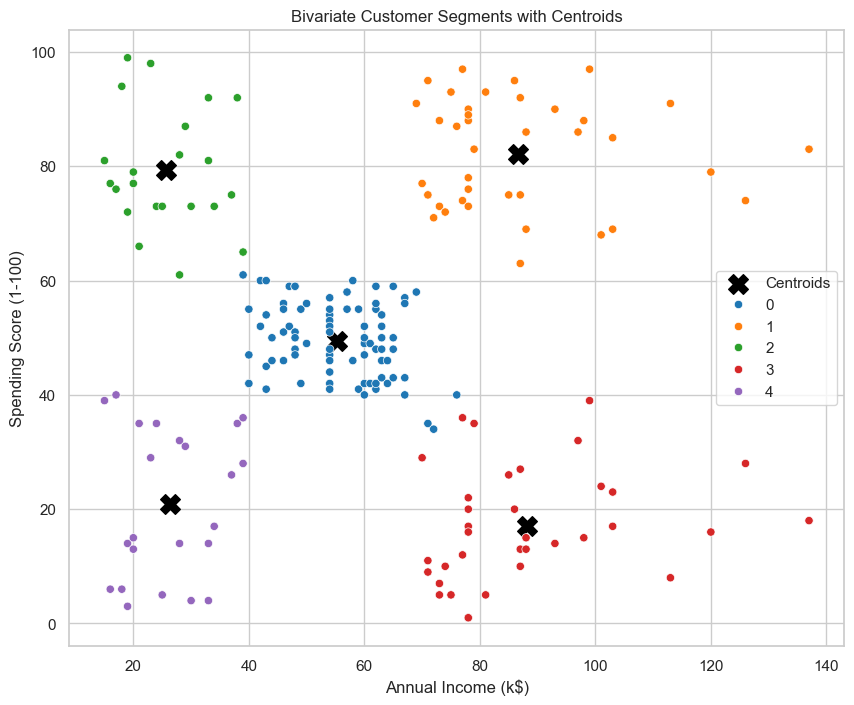

In [18]:
# 1. Extract the cluster centers (centroids) and convert them to a DataFrame
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

# 2. Create a large-scale scatter plot to visualize the segments
plt.figure(figsize=(10, 8))

# Plot the centroids as black 'X' markers
plt.scatter(x=centers['x'], y=centers['y'], s=200, c='black', marker='X', label='Centroids')

# Plot the individual customer points, colored by their assigned cluster
# We use the 'tab10' palette for professional, distinct coloring
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Spending_and_Income_Cluster', palette='tab10')

plt.title('Bivariate Customer Segments with Centroids')
plt.legend()

# Multivariate Analysis and Preprocessing
**One-Hot Encoding:** Converting the categorical 'Gender' column into numerical values using binary indicators

**Standardization:** Using a StandardScaler to put all variables on the same scale (mean of 0 and standard deviation of 1). This prevents variables with larger raw numbers, like Annual Income, from disproportionately influencing the algorithm

*A quick technical note on scaling: For the final multivariate model, I am applying a standard scaler to the data. Since K-Means groups data based on mathematical distance, we need to make sure variables with naturally smaller numbers (like Age) and larger numbers (like Annual Income) are treated equally. Scaling prevents the algorithm from just focusing on the bigger numbers and ignoring the rest.*

In [19]:
# Initialize the standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 1. Apply One-Hot Encoding to the Gender column
# drop_first=True is used to avoid the dummy variable trap (multicollinearity)
dff = pd.get_dummies(df, drop_first=True)

# 2. Select the specific features for the multivariate model
# We include our core numerical features and the newly encoded Gender_Male column
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']]

# 3. Apply the scaler to standardize the features
# We transform the data and convert the output back into a clean DataFrame
dff_scaled = pd.DataFrame(scaler.fit_transform(dff))

# View the head of the scaled dataframe to confirm the transformation
dff_scaled.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


Text(0, 0.5, 'Inertia')

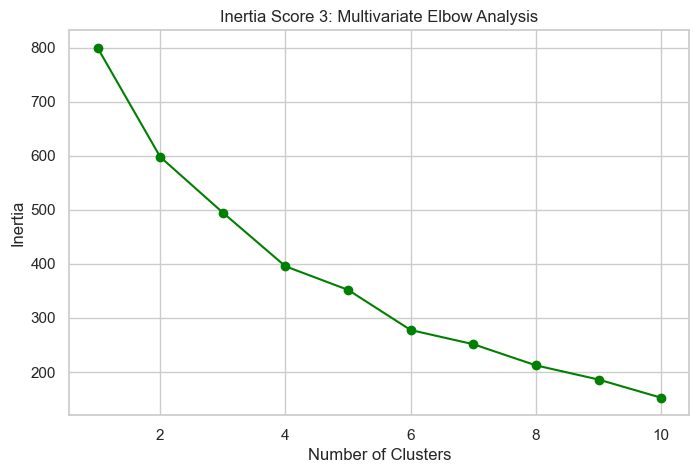

In [20]:
# Initialize a list for the third set of inertia scores
inertia_scores3 = []

# Loop through 1 to 10 clusters to find the optimal K for the full feature set
for i in range(1, 11):
    kmeans3 = KMeans(n_clusters=i, init='k-means++', random_state=42)
    # Fit the model to the fully scaled, multivariate dataset
    kmeans3.fit(dff_scaled)
    inertia_scores3.append(kmeans3.inertia_)

# Plot the multivariate elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_scores3, marker='o', color='green')
plt.title('Inertia Score 3: Multivariate Elbow Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

# Final Strategic Personas & Reporting
Based on our multivariate elbow analysis, we now execute the final K-Means algorithm to group customers across all four dimensions (Age, Gender, Income, and Spending Score). We then analyze the mean values of each group to identify distinct shopping personas.

### Executing Final Multivariate Clustering

In [21]:
# Initialize the final multivariate model with the chosen number of clusters (e.g., 5)
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Fit the model to the scaled dataset and extract the labels
# We add these labels to the original dataframe for easier interpretation
df['Multivariate_Cluster'] = kmeans_final.fit_predict(dff_scaled)

# View the head of the dataframe to confirm all cluster labels are present
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio,Income Cluster,Spending_and_Income_Cluster,Multivariate_Cluster
0,1,Male,19,15,39,2.600000,1,4,2
1,2,Male,21,15,81,5.400000,1,2,2
2,3,Female,20,16,6,0.375000,1,4,4
3,4,Female,23,16,77,4.812500,1,2,4
4,5,Female,31,17,40,2.352941,1,4,4


In [22]:
# Check how many customers are in each final persona
df['Multivariate_Cluster'].value_counts()

Multivariate_Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64

### Statistical Interpretation of Customer Segments
By grouping the data by our multivariate labels and calculating the mean for each feature, we can define the specific characteristics of each customer group.

In [23]:
# Group by the multivariate labels and calculate the mean for all numerical attributes
# This allows us to see which cluster represents the 'ideal' high-value target
final_analysis = df.groupby('Multivariate_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spend_Income_Ratio']].mean()

# Sort by Spending Score to prioritize high-value segments
final_analysis.sort_values(by='Spending Score (1-100)', ascending=False)

,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio
Multivariate_Cluster,,,,
2,28.690476,60.904762,70.238095,1.509964
4,27.315789,38.842105,56.210526,1.850623
3,37.897959,82.122449,54.448980,0.687783
0,56.470588,46.098039,39.313725,0.840769
1,39.500000,85.150000,14.050000,0.169301


### Strategic Persona Mapping
Based on the statistical findings, we translate the numerical clusters into actionable marketing personas.

In [24]:
# Aggregate the mean values for each multivariate cluster to define their profiles
# We sort by Spending Score to immediately identify our highest-value segments
final_analysis = df.groupby('Multivariate_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spend_Income_Ratio']].mean()
final_analysis.sort_values(by='Spending Score (1-100)', ascending=False)

,Age,Annual Income (k$),Spending Score (1-100),Spend_Income_Ratio
Multivariate_Cluster,,,,
2,28.690476,60.904762,70.238095,1.509964
4,27.315789,38.842105,56.210526,1.850623
3,37.897959,82.122449,54.448980,0.687783
0,56.470588,46.098039,39.313725,0.840769
1,39.500000,85.150000,14.050000,0.169301


# Strategic Recommendations & Analytical Takeaways
Based on the multivariate clustering analysis, we have identified five distinct segments. The following recommendations are designed to optimize marketing ROI by targeting the most "efficient" and high-value groups

**Primary Target (Cluster 2):** Target with high-frequency social media campaigns. With the highest spending score (70.2) and a young average age (28.7), they maintain a high Spend-to-Income Ratio of 1.51, making them the most consistently engaged shoppers despite moderate incomes

**Splurge Shoppers (Cluster 4):** arget with seasonal trend alerts and major product launches. This group has the highest Spend-to-Income Ratio (1.85) in the entire dataset. These are younger shoppers (Avg. Age 27.3) who efficiently "splurge" on big-ticket items like electronics or designer goods relative to their lower annual incomes.

**Wealthy Loyalists (Cluster 3):** Focus on retention through exclusivity. These are high-income earners ($82.1k) with stable spending (54.4) and a balanced Spend-to-Income Ratio of 0.69. Use premium loyalty rewards and exclusive previews to tap into their significant remaining purchasing power.

**Senior Frugals (Cluster 0):** Target with value-driven messaging emphasizing quality and durability. This is the oldest demographic (Avg. Age 56.5) with a conservative Spend-to-Income Ratio of 0.84. They are less influenced by fast-moving trends and prioritize "value-for-money" in their shopping behavior.

**Investigative Opportunity (Cluster 1):** Perform deep-dive qualitative research. These are high-earning individuals ($85.2k) with almost zero mall engagement, resulting in the lowest Spend-to-Income Ratio (0.17). We must identify if the mall lacks the specific luxury brands or high-end services required to convert this high-wealth segment into active shoppers.

# Project Conclusion

In this project, I successfully segmented a customer database of 200 mall visitors into five distinct personas using K-Means clustering.

### Key Insights & Achievements:

**Beyond Income:** I proved that income alone is a poor predictor of spending. By creating the 'Spend-to-Income Ratio', I identified a group of 'Splurge Shoppers' (Cluster 4) who are high-value targets despite having lower incomes.

**Mathematical Rigor:** I used the Elbow Method to justify the transition from a 3-cluster univariate model to a more precise 5-cluster multivariate model.

**Strategic Value:** Each cluster now has a specific marketing profile, allowing the mall to move from generic advertising to targeted campaigns that improve ROI.

This data-driven approach ensures that marketing resources are allocated to the most "efficient" shoppers, potentially increasing engagement while reducing wasted ad spend.

In [ ]:
# Export the final dataset to the specified folder path for use to the marketing team, CRM and so on.
#file_path = '/Library/DAP/python_customer_segmentation/Delivarables/Strategic_Customer_Segmentation_Final.csv'
#df.to_csv(file_path, index=False)

#print(f"Final dataset exported successfully to: {file_path}")

Final dataset exported successfully to: /Library/DAP/python_customer_segmentation/Delivarables/Strategic_Customer_Segmentation_Final.csv


### End of Analysis
